gpp_sum_anom  aCO2:  15.067008526692769
gpp_sum_anom  eCO2:  15.5726450559085
gpp_max_whsM_anom  aCO2:  0.11067818918380957
gpp_max_whsM_anom  eCO2:  0.08724591269841148
cup_whsM_25_anom  aCO2:  1.520447668435473
cup_whsM_25_anom  eCO2:  1.303911317393133
alpha_whsM_25_anom  aCO2:  0.0029894860903902963
alpha_whsM_25_anom  eCO2:  0.002586559849746013


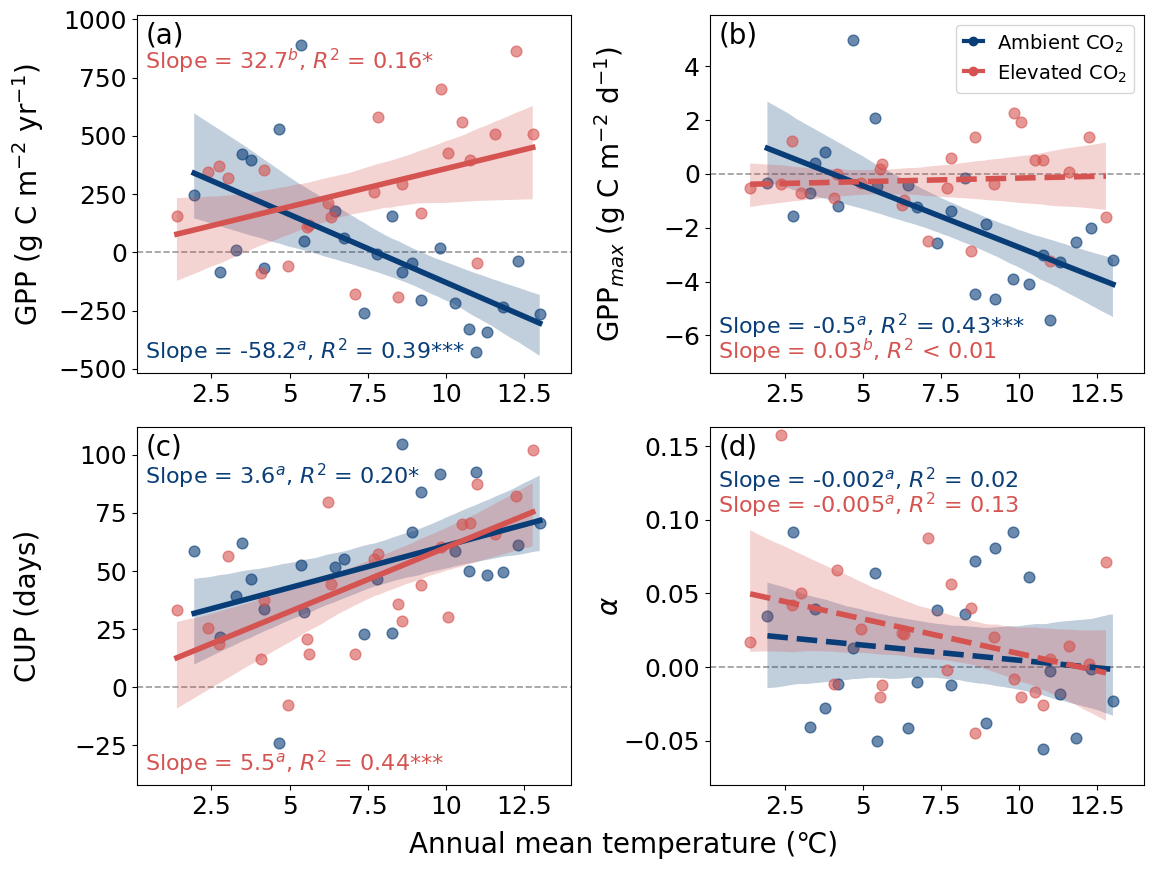

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# ============================================================
# 0) Read data
# ============================================================
df = pd.read_excel(
    "../../data_results/2_results/2-3_gppmax_cup_6methods/calculated_GPPmax_CUP_ampFracs_10_20_30_25_thresholdScope_ecosystem.xlsx"
)
df = df[(df["year"] > 2016)].copy()

# ============================================================
# 1) Helper: regression slope-difference test (interaction p)
# ============================================================
def cal_reg_diff(x1, y1, x2, y2, alpha=0.05):
    x = np.concatenate([x1, x2])
    y = np.concatenate([y1, y2])

    d = pd.DataFrame({
        "x": x,
        "y": y,
        "group": np.r_[np.repeat(1, len(x1)), np.repeat(2, len(x2))]
    })
    d["group"] = d["group"].astype("category")

    # y ~ x + group + x:group
    model = smf.ols("y ~ x + C(group) + x:C(group)", data=d).fit()

    term = [n for n in model.pvalues.index if (":" in n) and ("x" in n) and ("C(group)" in n)]
    if len(term) != 1:
        raise KeyError(f"Cannot uniquely identify interaction term. Found: {term}")

    p_int = model.pvalues[term[0]]
    return ("a", "b") if p_int < alpha else ("a", "a")

# ============================================================
# 2) Helper: fit linear/quadratic and choose by AIC
#    Rule: choose quadratic if AIC_quad < AIC_lin - aic_delta
# ============================================================
def fit_models_and_choose(x, y, aic_delta=4.0, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # --- linear
    X1 = sm.add_constant(x)
    m1 = sm.OLS(y, X1).fit()
    aic1 = m1.aic
    p1 = m1.f_pvalue

    # --- quadratic
    X2 = sm.add_constant(np.column_stack([x, x**2]))
    m2 = sm.OLS(y, X2).fit()
    aic2 = m2.aic
    p2 = m2.f_pvalue

    if aic_delta is not None and  aic2 < aic1 - aic_delta:
        chosen = "quad"
        model = m2
        p_model = p2
    else:
        chosen = "linear"
        model = m1
        p_model = p1

    linestyle = "-" if p_model < alpha else "--"
    stars = "***" if p_model < 0.001 else ("**" if p_model < 0.01 else ("*" if p_model < 0.05 else ""))

    ci = model.conf_int()
    return {
        "chosen": chosen,
        "model": model,
        "p_model": p_model,
        "linestyle": linestyle,
        "stars": stars,
        "aic_lin": aic1,
        "aic_quad": aic2,

        # slope uncertainty
        "slope": float(model.params[1]),
        "slope_se": float(model.bse[1]),
        "slope_ci_low": float(ci[1][0] if isinstance(ci, np.ndarray) else ci.iloc[1, 0]),
        "slope_ci_high": float(ci[1][1] if isinstance(ci, np.ndarray) else ci.iloc[1, 1]),
    }

# ============================================================
# 3) Helper: equation text (simple + clean)
#    - Only show y^{a/b} when BOTH fits are linear
#    - If intercept < 0 -> use "-" (no "+ -")
#    - Do not show terms with ~0 (e.g., intercept ~ 0)
# ============================================================
def format_two_equations(
    fit1, fit2,
    sup1="a", sup2="b",
    nd_slope=2, nd_int=2, nd_r2=2,
    tol=1e-8
):
    def is_linear(fit):
        return fit["chosen"] == "linear"

    def is_zero(v):
        try:
            return (v is None) or (np.isnan(v)) or (abs(float(v)) < tol)
        except Exception:
            return True

    def fmt(v, nd):
        if is_zero(v):
            return None
        if abs(v) >=1:
            s = f"{float(v):.{nd}f}".rstrip("0").rstrip(".")
        else:
            s = f"{v:.1g}"
        return None if s in ("-0", "-0.0", "-0.00") else s

    def linear_eq(fit, slope_sup=None):
        b0, b1 = fit["model"].params  # const, x
        ytxt = "y" #if y_sup is None else rf"y$^{{{y_sup}}}$"
        

        parts = []
        if not is_zero(b1):
            b1s = fmt(b1, nd_slope)
            if b1s is not None:
                parts.append(f"{b1s}x" if slope_sup is None else rf"{b1s}$^{{{slope_sup}}}$x")

        if not is_zero(b0):
            b0abs = fmt(abs(b0), nd_int)
            if b0abs is not None:
                parts.append(f"+ {b0abs}" if b0 > 0 else f"- {b0abs}")

        rhs = " ".join(parts).strip()
        if rhs == "":
            rhs = "0"

        r2 = fit["model"].rsquared
        r2s = f"{r2:.{nd_r2}f}"
        # return f"{ytxt} = {rhs}; R$^2$ = {r2s}$^{{{fit['stars']}}}$" if r2 > 0.01 else f"{ytxt} = {rhs}; R$^2$ < 0.01"
        return (
                f"Slope = {b1s}$^{{{slope_sup}}}$, "
                f"$R^2$ = {r2s}{fit['stars']}"
                if r2 > 0.01
                else
                f"Slope = {b1s}$^{{{slope_sup}}}$, $R^2$ < 0.01"
            )

    def quad_eq(fit):
        # const, x, x^2
        b0, b1, b2 = fit["model"].params
        r2 = fit["model"].rsquared
        r2s = f"{r2:.{nd_r2}f}" 
        # keep it simple; you can modify formatting here
        eq = f"y = {b2:.1f}x$^2$ + {b1:.1f}x + {b0:.1f}"
        eq = eq.replace("+ -", "- ")
        return f"{eq}; R$^2$ = {r2s}$^{{{fit['stars']}}}$" if r2 > 0.01 else f"{eq}; R$^2$ < 0.01"

    both_linear = is_linear(fit1) and is_linear(fit2)

    eq1 = linear_eq(fit1, slope_sup=sup1 if both_linear else None) if is_linear(fit1) else quad_eq(fit1)
    eq2 = linear_eq(fit2, slope_sup=sup2 if both_linear else None) if is_linear(fit2) else quad_eq(fit2)

    return eq1, eq2

# ============================================================
# 4) Helper: draw regression (seaborn regplot)
# ============================================================
def draw_reg(ax, x, y, color, order, linestyle, scatter_alpha=0.6, line_alpha=1.0):
    # ax.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.6)
    sns.regplot(
        x=x, y=y, ax=ax,
        order=order,
        scatter_kws={"alpha": scatter_alpha, "color": color, "s": 60},
        line_kws={"linestyle": linestyle, "alpha": line_alpha, "linewidth": 4},
        color=color
    )
    # lighten CI band if exists
    if len(ax.collections) > 1:
        ax.collections[-1].set_alpha(0.25)

# ============================================================
# 5) Plot settings
# ============================================================
x_col = "temp_mean_anom"
co2_col = "co2"
aCO2_value = 0
eCO2_value = 500

vars_to_plot = [
    ("gpp_sum_anom", "GPP (g C m$^{-2}$ yr$^{-1}$)", (-519, 1019)),
    ("gpp_max_whsM_anom", "GPP$_{max}$ (g C m$^{-2}$ d$^{-1}$)", (-7.4, 5.9)),
    ("cup_whsM_25_anom",     "CUP (days)", (-42, 112)),
    ("alpha_whsM_25_anom",   r"$\alpha$", (-0.08, 0.163))
]
subtitles = ["(a)", "(b)", "(c)", "(d)"]

# Text positions: ((x, y_blue), (x, y_red))
text_pos = {
    "gpp_sum_anom": ((0.02, 0.02), (0.02, 0.83)),
    "gpp_max_whsM_anom": ((0.02, 0.09), (0.02, 0.02)),
    "cup_whsM_25_anom":     ((0.02, 0.82), (0.02, 0.02)),
    "alpha_whsM_25_anom":   ((0.02, 0.81), (0.02, 0.74)),
}

# blue = "#346099"
# red  = "#e0614a"
# blue = "#015369"
# red  = "#fdb58d"
# red = "#ed5736"
blue = "#093D77"
red = "#d55350"

x_ticks = [2.5, 5, 7.5, 10, 12.5]

# ============================================================
# 6) Plot
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (var, ylabel, ylims) in enumerate(vars_to_plot):
    ax = axes[i]
    ax.text(0.02, 0.92, subtitles[i], transform=ax.transAxes, fontsize=20)

    ax.set_xlim(0.1, 14)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks)
    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=18)
    ax.set_ylim(ylims)
    ax.axhline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.8, zorder=0)

    # group data
    d1 = df[df[co2_col] == aCO2_value]
    d2 = df[df[co2_col] == eCO2_value]

    x1 = d1[x_col].to_numpy(float)
    y1 = d1[var].to_numpy(float)

    x2 = d2[x_col].to_numpy(float)
    y2 = d2[var].to_numpy(float)

    # y1 = np.log(y1)
    # y2 = np.log(y2)

    # (a/b) marker:
    # - For CUP: test slope difference (interaction p)
    # - Else: test mean difference (t-test)
    # if var == "cup_anom":
    sup1, sup2 = cal_reg_diff(x1, y1, x2, y2, alpha=0.05)
    # else:
    #     _, p_y = stats.ttest_ind(y1, y2, equal_var=False)
    #     sup1, sup2 = ("a", "b") if p_y < 0.05 else ("a", "a")

    # Fit + choose by AIC rule
    fit1 = fit_models_and_choose(x1, y1, aic_delta=None, alpha=0.05)
    fit2 = fit_models_and_choose(x2, y2, aic_delta=None, alpha=0.05)

    print(var, " aCO2: ",fit1["slope_se"])
    print(var, " eCO2: ",fit2["slope_se"])

    # Draw
    draw_reg(ax, x1, y1, color=blue, order=1 if fit1["chosen"] == "linear" else 2, linestyle=fit1["linestyle"])
    draw_reg(ax, x2, y2, color=red,  order=1 if fit2["chosen"] == "linear" else 2, linestyle=fit2["linestyle"])

    # Equations (superscripts only if both linear)
    (tx_blue, ty_blue), (tx_red, ty_red) = text_pos[var]
    eq1, eq2 = format_two_equations(fit1, fit2, sup1=sup1, sup2=sup2, nd_slope=1, nd_int=1, nd_r2=2, tol=1e-8)

    ax.text(tx_blue, ty_blue, eq1, fontsize=16, transform=ax.transAxes, color=blue, va="bottom")
    ax.text(tx_red,  ty_red,  eq2, fontsize=16, transform=ax.transAxes, color=red,  va="bottom")

    # Y label (manual position)
    xoff = -0.25 if i in (0, 2) else -0.23
    ax.text(xoff, 0.5, ylabel, ha="center", va="center",
            rotation="vertical", transform=ax.transAxes, fontsize=20)

# Legend (custom handles)
import matplotlib.lines as mlines
blue_line = mlines.Line2D([], [], color=blue, marker="o", linestyle="-", linewidth=3, label="Ambient CO$_2$")
red_line  = mlines.Line2D([], [], color=red, marker="o", linestyle="-", linewidth=3, label="Elevated CO$_2$")

axes[1].legend(
    loc="upper right",
    handles=[blue_line, red_line],
    fontsize=14,
    handlelength=1.0,
    handleheight=1.2,
    handletextpad=0.7,
    labelspacing=0.4,
    borderpad=0.4,
)

fig.text(0.5, 0.05, "Annual mean temperature (℃)", fontsize=20, ha="center", va="center")
plt.subplots_adjust(hspace=0.15, wspace=0.32)
plt.show()